# Atividade: CNNs para Classificação

Neste notebook, iremos preparar nosso próprio dataset e treinar um modelo de classificação de imagens.

## Preparando os dados

Os dados desta atividade serão baixados da internet. Utilizaremos para isso buscadores comuns. Em seguida, dividiremos em treinamento e validação.

In [13]:
import os
import shutil
import random
!pip install icrawler
from icrawler.builtin import GoogleImageCrawler, BingImageCrawler

### Adquirindo as Imagens

Utilizaremos o iCrawler para baixar imagens em buscadores através de termos especificados. Defina sua lista de classes.

In [14]:
def download_images(keyword, folder, n_total=100):
    os.makedirs(folder, exist_ok=True)
    downloaded = len(os.listdir(folder))
    remaining = n_total - downloaded

    while downloaded < n_total:
        crawler = BingImageCrawler(storage={'root_dir': folder})
        crawler.crawl(keyword=keyword, max_num=remaining, file_idx_offset=downloaded)
        downloaded = len(os.listdir(folder))
        remaining = n_total - downloaded
        print(f"Downloaded {downloaded}/{n_total}")

    print("Download complete!")

In [15]:
search_terms = {
    "cat": "black cat",
    "dog" : "black dog"
}

for label, term in search_terms.items():
    download_images(term, f"data/animals/{label}", n_total=100)

Download complete!
Download complete!


In [16]:
import pandas as pd

image_dir = "data/animals"
classes = ["cat", "dog"]

rows = []

for label_id, class_name in enumerate(classes):
    class_folder = os.path.join(image_dir, class_name)
    for fname in os.listdir(class_folder):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            rows.append([f"{class_name}/{fname}", label_id])

labels_df = pd.DataFrame(rows, columns=["image", "label"])
labels_df.head(-1)

,image,label
0,cat/000010.jpg,0
1,cat/000084.jpg,0
2,cat/000079.jpg,0
3,cat/000014.jpg,0
4,cat/000067.jpg,0
...,...,...
194,dog/000094.jpg,1
195,dog/000056.jpg,1
196,dog/000081.jpg,1
197,dog/000019.jpg,1


### Treinamento e Validação

Dividiremos as imagens baixadas nas pastas `train` e `val`. Defina uma porcentagem.

In [17]:
def split_train_val(root_dir, train_ratio=0.8, seed=42):
    random.seed(seed)

    train_dir = root_dir + "_split/train"
    val_dir = root_dir + "_split/val"

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)

    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [os.path.join(class_path, f) for f in os.listdir(class_path)]
        images = [f for f in images if os.path.isfile(f)]
        random.shuffle(images)

        n_train = int(len(images) * train_ratio)

        train_class_dir = os.path.join(train_dir, class_name)
        val_class_dir = os.path.join(val_dir, class_name)
        os.makedirs(train_class_dir, exist_ok=True)
        os.makedirs(val_class_dir, exist_ok=True)

        for img in images[:n_train]:
            shutil.copy(img, os.path.join(train_class_dir, os.path.basename(img)))
        for img in images[n_train:]:
            shutil.copy(img, os.path.join(val_class_dir, os.path.basename(img)))

        print(f"{class_name}: {n_train} train, {len(images)-n_train} val")

In [26]:
split_train_val("data/animals")

dog: 80 train, 20 val
cat: 80 train, 20 val


## Dataset

Implemente um Dataset PyTorch que carregue as imagens baixadas com suas respectivas classes. Aplique data augmentation e carregue em batches.

In [27]:
from torch.utils.data import Dataset
import os
import pandas as pd
from PIL import Image
from torchvision import transforms

class CustomImageDataset(Dataset):
    def __init__(self, root_dir, classes, transform=None):
        self.root_dir = root_dir
        self.classes = classes
        self.transform = transform
        self.image_paths = []
        self.labels = []

        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}

        for label_id, class_name in enumerate(self.classes):
            class_folder = os.path.join(self.root_dir, class_name)
            if not os.path.isdir(class_folder):
                print(f"Aviso: Pasta da classe '{class_name}' não encontrada em '{self.root_dir}'")
                continue
            for fname in os.listdir(class_folder):
                if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    self.image_paths.append(os.path.join(class_folder, fname))
                    self.labels.append(label_id)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [28]:
from torchvision import transforms

data_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

classes = ["cat", "dog"]

train_dataset = CustomImageDataset(
    root_dir="data/animals_split/train",
    classes=classes,
    transform=data_transforms
)

val_dataset = CustomImageDataset(
    root_dir="data/animals_split/val",
    classes=classes,
    transform=data_transforms
)

## Definição do Modelo

Defina aqui o modelo que será utilizado, sendo implementação própria ou um modelo pré-treinado. Teste diversas arquiteturas diferentes e verifique qual delas tem melhor desempenho em validação.

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import numpy as np
import time
import os


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo de treinamento: {DEVICE}\n")

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
NUM_CLASSES = 2


cnn_model = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Flatten(),

    nn.Linear(in_features=32 * 16 * 16, out_features=NUM_CLASSES),
)

model = cnn_model.to(DEVICE)
print(f"Número total de parâmetros: {count_parameters(model):,}")
print("-" * 50)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)

def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1);

            total += labels.size(0)
            correct += (predicted == labels).sum().item();

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    return accuracy, all_labels, all_preds

Dispositivo de treinamento: cuda

Número total de parâmetros: 21,474
--------------------------------------------------


## Treinamento

Defina a função de custo e o otimizador do modelo. Em seguida, implemente o código de treinamento e treine-o. Ao final, exiba as curvas de treinamento e validação para a loss e a acurácia.

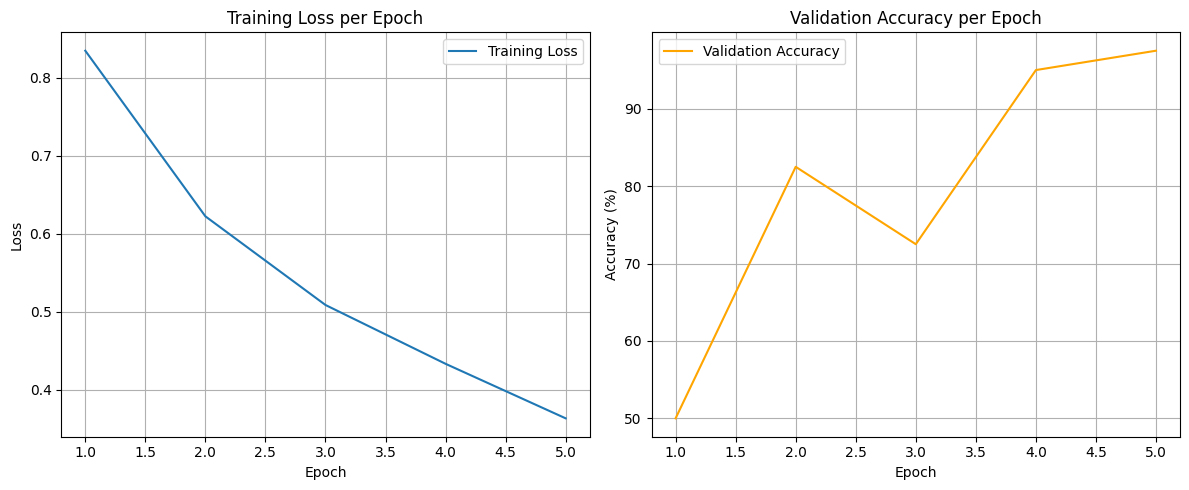

In [30]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch')
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(range(1, NUM_EPOCHS + 1), val_accuracies, label='Validation Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy per Epoch')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [33]:
NUM_EPOCHS = 5
LEARNING_RATE = 0.0001
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Iniciando treinamento por {NUM_EPOCHS} épocas no dataset de animais...")
best_accuracy = 0

train_losses = []
val_accuracies = []

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    train_loss = train_epoch(model, train_loader, criterion, optimizer, DEVICE)

    val_accuracy, _, _ = evaluate(model, val_loader, DEVICE)

    end_time = time.time()

    print(f"Época {epoch+1}/{NUM_EPOCHS} | "
          f"Perda de Treinamento: {train_loss:.4f} | "
          f"Acurácia de Validação: {val_accuracy:.2f}% | "
          f"Tempo: {end_time - start_time:.2f}s")

    train_losses.append(train_loss)
    val_accuracies.append(val_accuracy)

print("-" * 50)
print("Treinamento concluído.")

Iniciando treinamento por 5 épocas no dataset de animais...
Época 1/5 | Perda de Treinamento: 0.5391 | Acurácia de Validação: 77.50% | Tempo: 7.85s
Época 2/5 | Perda de Treinamento: 0.5112 | Acurácia de Validação: 82.50% | Tempo: 8.52s
Época 3/5 | Perda de Treinamento: 0.4927 | Acurácia de Validação: 85.00% | Tempo: 8.25s
Época 4/5 | Perda de Treinamento: 0.4704 | Acurácia de Validação: 92.50% | Tempo: 7.58s
Época 5/5 | Perda de Treinamento: 0.4479 | Acurácia de Validação: 87.50% | Tempo: 8.35s
--------------------------------------------------
Treinamento concluído. O melhor modelo foi salvo como 'cnn_animals_best_model.pth'.


DEBUG - Sample 115 (Normalized) Min/Max: -1.8610/2.3786
DEBUG - Sample 30 (Normalized) Min/Max: -1.9980/2.6226


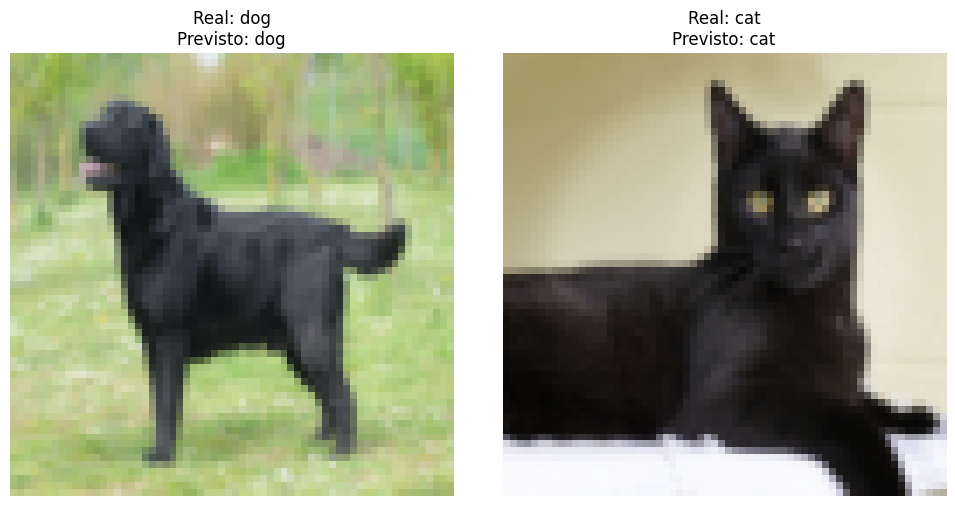

In [36]:
import matplotlib.pyplot as plt
from torchvision.transforms import ToPILImage
import random
import numpy as np

model.eval()

to_pil = ToPILImage()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))


num_samples_to_plot = 2
random_indices = random.sample(range(len(train_dataset)), num_samples_to_plot);


class_names = classes;

for i, idx in enumerate(random_indices):
    image_tensor, true_label_id = train_dataset[idx];
    image_input = image_tensor.unsqueeze(0).to(DEVICE);

    with torch.no_grad():
        output = model(image_input);
        _, predicted_label_id = torch.max(output, 1);


    mean = np.array([0.485, 0.456, 0.406]);
    std = np.array([0.229, 0.224, 0.225]);
    img_display = image_tensor.cpu().numpy();

    img_display = img_display * std[:, None, None] + mean[:, None, None];
    img_display = np.clip(img_display, 0, 1);
    img_display = np.transpose(img_display, (1, 2, 0));

    true_label_name = class_names[true_label_id];
    predicted_label_name = class_names[predicted_label_id.item()];

    axes[i].imshow(img_display);
    axes[i].set_title(f"Real: {true_label_name}\nPrevisto: {predicted_label_name}");
    axes[i].axis('off');

plt.tight_layout();
plt.show()

## Inferência

Calcule algumas métricas como acurácia, matriz de confusão, etc. Em seguida, teste o modelo em novas imagens das classes correspondentes mas de outras fontes (outro buscador, fotos próprias, etc).

In [35]:
model.load_state_dict(torch.load('cnn_animals_best_model.pth'))


final_accuracy, true_labels, predictions = evaluate(model, val_loader, DEVICE)


cm = confusion_matrix(true_labels, predictions);

print("\n--- MATRIZ DE CONFUSÃO ---")

print(cm);
print(f"\nAcurácia Final no Conjunto de Validação: {final_accuracy:.2f}%");


--- MATRIZ DE CONFUSÃO ---
[[20  0]
 [ 3 17]]

Acurácia Final no Conjunto de Validação: 92.50%

Nota: As linhas representam os valores verdadeiros; as colunas representam as previsões.
